In [1]:
import pandas as pd

df = pd.read_json("../data/data.json")

df["route"] = df["origin_country"] + " → " + df["receiving_country"]

print("Number of unique routes:", df["route"].nunique())

df[["origin_country", "receiving_country", "route"]].head()

Number of unique routes: 4124


,origin_country,receiving_country,route
0,Uzbekistan,Netherlands,Uzbekistan → Netherlands
1,Uzbekistan,Latvia,Uzbekistan → Latvia
2,Uzbekistan,Netherlands,Uzbekistan → Netherlands
3,Uzbekistan,Germany,Uzbekistan → Germany
4,Uzbekistan,Malaysia,Uzbekistan → Malaysia


In [2]:
top_routes = df["route"].value_counts().head(15)

print("Top 15 routes:")
print(top_routes)

Top 15 routes:
route
Colombia → Russia            22
India → Germany              22
French Polynesia → Russia    20
Malawi → Russia              20
Niger → Germany              19
Peru → Russia                18
Grenada → Russia             18
Barbados → U.S.A.            17
American Samoa → U.S.A.      17
Austria → Germany            17
Bangladesh → Germany         17
Palau → Germany              17
Italy → Germany              16
Micronesia → Germany         16
Panama → Russia              16
Name: count, dtype: int64


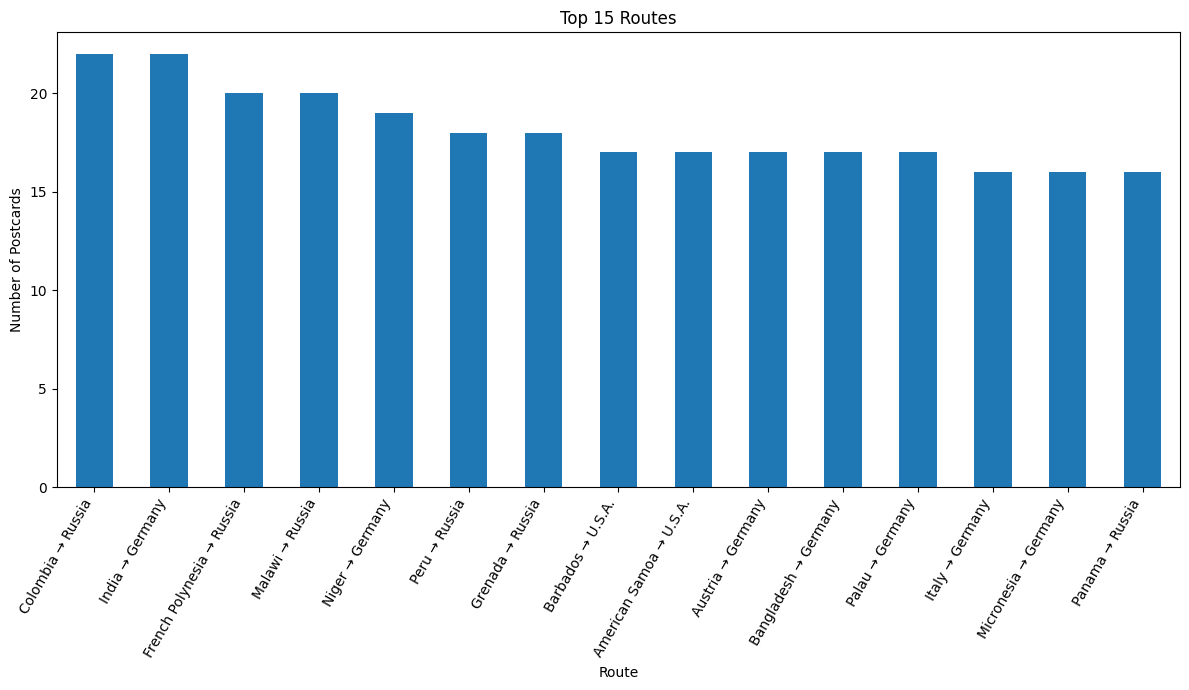

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
top_routes.plot(kind="bar")
plt.title("Top 15 Routes")
plt.xlabel("Route")
plt.ylabel("Number of Postcards")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [4]:
origin_diversity = (
    df.groupby("origin_country")["receiving_country"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 origin countries by number of unique destinations:")
print(origin_diversity)

Top 15 origin countries by number of unique destinations:
origin_country
Tuvalu                      29
Korea (North)               29
Portugal                    28
Canada                      26
Lesotho                     25
Croatia                     25
Denmark                     25
Kuwait                      24
Gibraltar                   24
Cyprus                      24
South Africa                24
Bosnia-Herzegovina          24
Syria                       24
Dominica                    24
Virgin Islands (British)    24
Name: receiving_country, dtype: int64


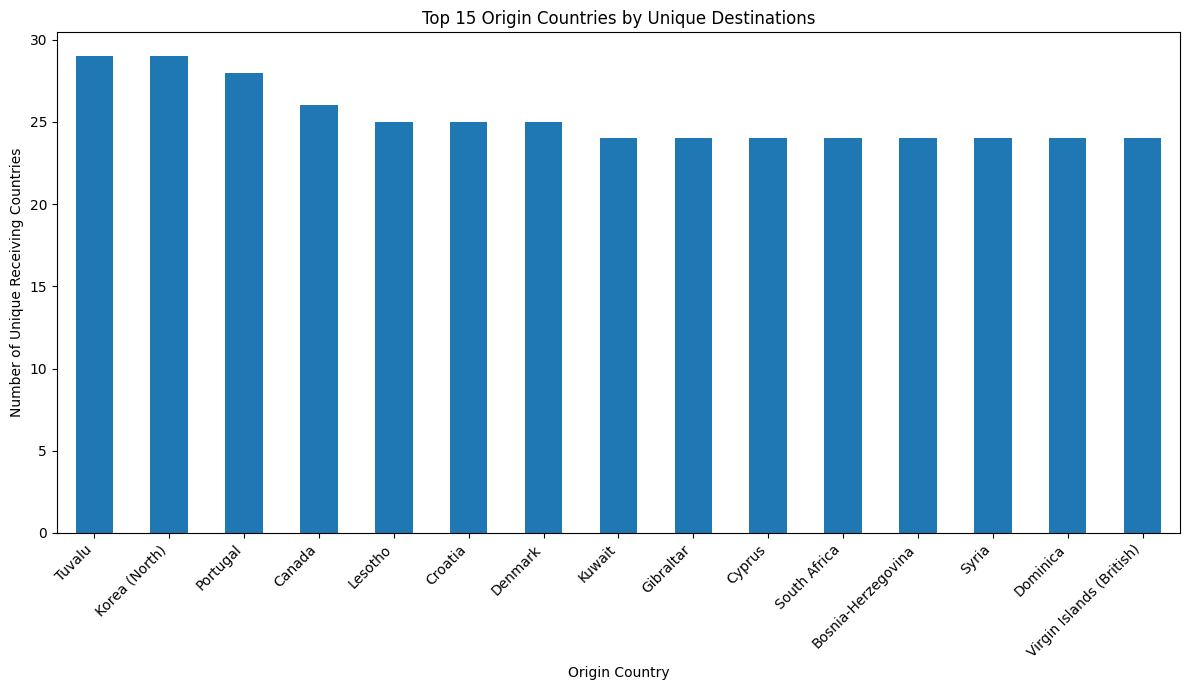

In [5]:
plt.figure(figsize=(12, 7))
origin_diversity.plot(kind="bar")
plt.title("Top 15 Origin Countries by Unique Destinations")
plt.xlabel("Origin Country")
plt.ylabel("Number of Unique Receiving Countries")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
route_time = (
    df.groupby("route")["time"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 routes by average transit time:")
print(route_time)

Top 15 routes by average transit time:
route
Uganda → Türkiye                         345.0
Pakistan → Finland                       344.0
Dominican Republic → Hong Kong           342.0
Cuba → Ireland                           333.0
French Southern Territories → Austria    325.0
Turkmenistan → Romania                   323.0
Zambia → Ukraine                         317.0
Zambia → Taiwan                          316.0
Morocco → Belgium                        314.0
Cameroon → Lithuania                     309.0
Montenegro → Slovakia                    307.0
Palestine → France                       301.0
El Salvador → Taiwan                     299.0
Antarctica → Russia                      289.0
Guatemala → Hong Kong                    283.0
Name: time, dtype: float64


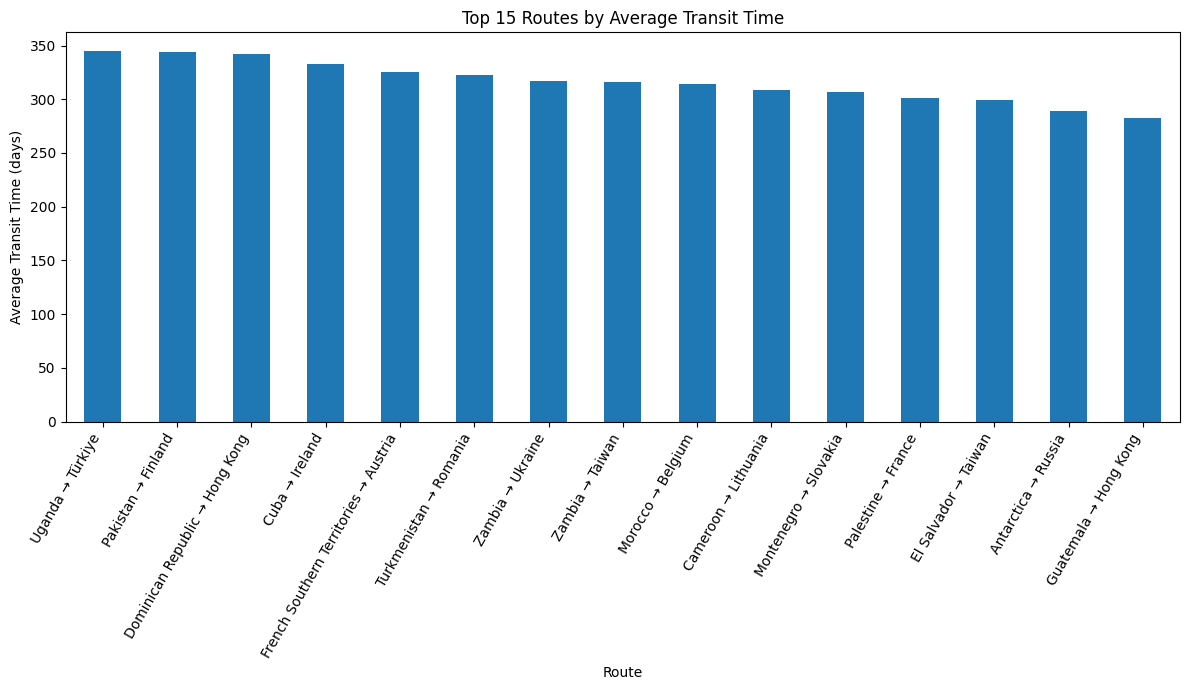

In [7]:
plt.figure(figsize=(12, 7))
route_time.plot(kind="bar")
plt.title("Top 15 Routes by Average Transit Time")
plt.xlabel("Route")
plt.ylabel("Average Transit Time (days)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()